# 3. MMM TRANSFORMATION
## HairBright · Marketing Mix Modeling — Revenue Prediction

---

**Input:** `data/interim/hairbright_clean_YYYYMMDD.xlsx`  
*Weekly-aggregated clean dataset produced by notebook 01.*

**Outputs:**
- `data/processed/hairbright_mmm_features_v2_YYYYMMDD.xlsx` — final feature matrix with all corrections (recommended input for notebook 04)
- `data/processed/hairbright_mmm_features_v1_YYYYMMDD.xlsx` — alternative version saved exclusively for diagnostic comparison in notebook 05

---

---
## 3.1. INITIAL SETUP

**Libraries used:**
- `pandas` / `numpy`: Data manipulation and numerical operations
- `matplotlib` / `seaborn`: Visualization of transformations
- `scipy.stats`: Statistical validation
- `sklearn.preprocessing`: StandardScaler for control variable normalization
- `pathlib`: File path management

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Libraries loaded successfully')
print(f'Pandas version : {pd.__version__}')
print(f'NumPy version  : {np.__version__}')

from google.colab import drive
drive.mount('/content/drive')

PATH_PROJECT   = Path('/content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty')
PATH_INTERIM   = PATH_PROJECT / 'data' / 'interim'
PATH_PROCESSED = PATH_PROJECT / 'data' / 'processed'
PATH_PROCESSED.mkdir(parents=True, exist_ok=True)

print('Project paths:')
print(f'  Interim   : {PATH_INTERIM}')
print(f'  Processed : {PATH_PROCESSED}')

Libraries loaded successfully
Pandas version : 2.2.2
NumPy version  : 2.0.2
Mounted at /content/drive
Project paths:
  Interim   : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/interim
  Processed : /content/drive/MyDrive/PRO/+ DATA SCIENCE/TFM/marketing-mix-modeling-beauty/data/processed


---
## 3.2. DATA LOADING AND SPEND SCALE FIX

We load the most recent clean file from `interim/` and apply two corrections before any transformation:

1. **Spend scale fix** — The raw dataset stores some monetary values at sub-unit precision (÷1e9). Notebook 01 correctly fixed revenue and discount columns, but a subset of spend rows retain the original scale. Specifically, any spend value ≥ 1,000,000 is still in sub-unit form and must be divided by 1e9. Values < 1,000,000 are already correct USD amounts.
2. **Derived columns** — `spend_total`, `roas_total` and `cac` are computed here as they depend on the corrected spend values.

> **Diagnosis:** `spend_ps` has 60/74 rows ≥ 1e6 (sub-unit scale) and 14 rows < 1e6 (correct scale). The bimodal distribution is the result of the median imputation in notebook 01 being applied to already sub-unit-scaled data for some rows, while other rows came through at the correct scale from the source.

In [2]:
# Load most recent interim file
interim_files = sorted(PATH_INTERIM.glob('hairbright_clean_*.xlsx'))
assert len(interim_files) > 0, 'No interim files found — run notebook 01 first.'
FILE_CLEAN = interim_files[-1]

df = pd.read_excel(FILE_CLEAN, parse_dates=['week'])
print(f'File loaded  : {FILE_CLEAN.name}')
print(f'Dimensions   : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Week range   : {df["week"].min().date()} → {df["week"].max().date()}')

# ── Spend scale fix ──────────────────────────────────────────────────────────
# Any spend value ≥ 1e6 is in sub-unit scale (÷1e9 to convert to USD).
# Values < 1e6 are already correct USD amounts.
# spend_video is excluded: all its values are already in correct USD scale
# (max=$203, no rows >= 1e6). Including it would be harmless but misleading.
SPEND_COLS_TO_FIX = ['spend_ps', 'spend_pmax', 'spend_display',
                     'spend_fb', 'spend_ig', 'spend_meta_other']
SPEND_COLS_ALL    = SPEND_COLS_TO_FIX + ['spend_video']  # all spend cols for totals
SCALE_THRESHOLD   = 1e6

rows_fixed = {}
for col in SPEND_COLS_TO_FIX:
    mask = df[col] >= SCALE_THRESHOLD
    rows_fixed[col] = mask.sum()
    df.loc[mask, col] = df.loc[mask, col] / 1e9

print('Spend scale correction (rows ÷1e9 per column):')
for col, n in rows_fixed.items():
    print(f'  {col:<22} {n:>3} rows fixed')

# ── Derived columns ───────────────────────────────────────────────────────────
df['spend_total'] = df[SPEND_COLS_ALL].sum(axis=1)
df['roas_total']  = df['revenue'] / df['spend_total'].replace(0, np.nan)
df['cac']         = df['spend_total'] / df['orders_total'].replace(0, np.nan)

print(f'\nPost-fix spend_total : ${df["spend_total"].min():,.2f} – ${df["spend_total"].max():,.2f}/week')
print(f'Post-fix roas_total  : {df["roas_total"].min():,.2f}x – {df["roas_total"].max():,.2f}x')
print(f'Revenue range        : ${df["revenue"].min():,.0f} – ${df["revenue"].max():,.0f}/week')
print(f'Overall ROAS         : {df["revenue"].sum() / df["spend_total"].sum():.2f}x')

File loaded  : hairbright_clean_20260415.xlsx
Dimensions   : 74 rows × 43 columns
Week range   : 2022-07-25 → 2023-12-18
Spend scale correction (rows ÷1e9 per column):
  spend_ps                 0 rows fixed
  spend_pmax               0 rows fixed
  spend_display            0 rows fixed
  spend_fb                 0 rows fixed
  spend_ig                 0 rows fixed
  spend_meta_other         0 rows fixed

Post-fix spend_total : $1,108.10 – $18,029.20/week
Post-fix roas_total  : 3.63x – 47.16x
Revenue range        : $10,340 – $474,930/week
Overall ROAS         : 12.78x


---
## 3.3. TARGET VARIABLE: LOG TRANSFORMATION

**Why log-transform revenue?**

Weekly revenue has a skewness of ~5.5 driven by the Black Friday spike. A log transformation:
- Reduces skewness from 5.5 → ~1.1, approaching normality
- Stabilizes variance (heteroscedasticity in the raw series violates OLS assumptions)
- Produces **multiplicative** MMM coefficients: a one-unit increase in log-transformed media → % change in revenue
- Is standard practice in MMM literature (Jin et al., 2017; Robyn by Meta, Meridian by Google)

> **Interpretation:** The MMM will be estimated on `log(revenue)`. Coefficients are interpreted as elasticities. To recover revenue in USD, exponentiate the model output.

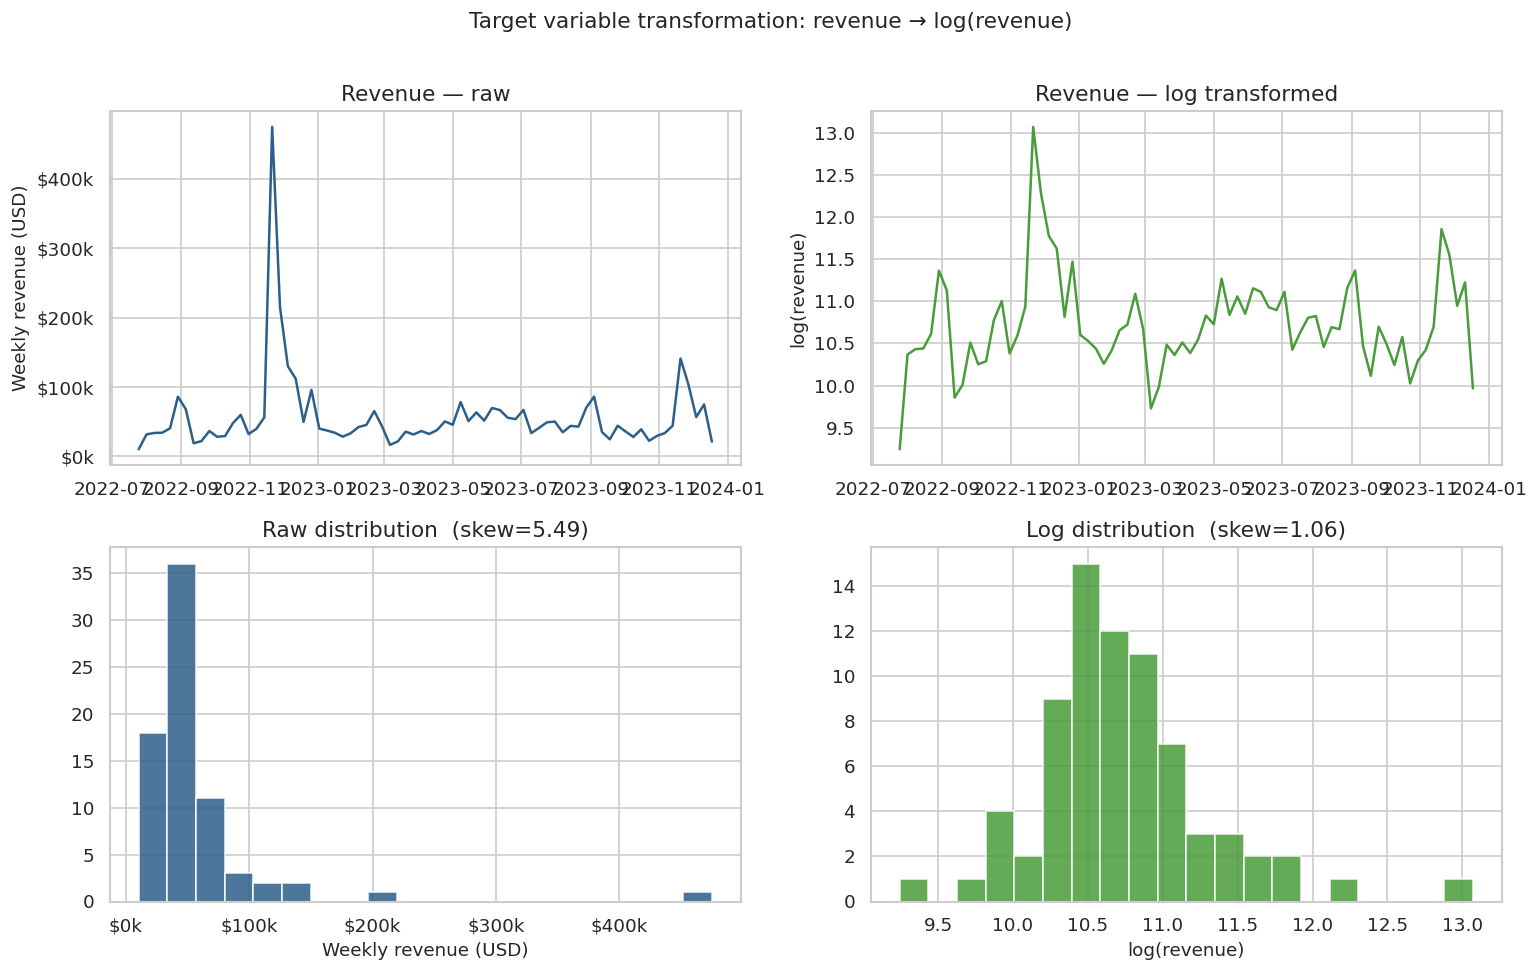

Normality (Shapiro-Wilk):
  Raw revenue  : W=0.4758,  p=0.0000  → Non-normal
  Log revenue  : W=0.9344,  p=0.0008  → Non-normal (skew residual from BF spike)


In [3]:
# Log-transform revenue
df['log_revenue'] = np.log(df['revenue'])

# Before / after comparison
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Raw revenue — time series
axes[0, 0].plot(df['week'], df['revenue'], color='#2C5F8A', linewidth=1.5)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0, 0].set_title('Revenue — raw')
axes[0, 0].set_ylabel('Weekly revenue (USD)')

# Log revenue — time series
axes[0, 1].plot(df['week'], df['log_revenue'], color='#4A9B3A', linewidth=1.5)
axes[0, 1].set_title('Revenue — log transformed')
axes[0, 1].set_ylabel('log(revenue)')

# Raw revenue — distribution
axes[1, 0].hist(df['revenue'], bins=20, color='#2C5F8A', edgecolor='white', alpha=0.85)
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 0].set_title(f'Raw distribution  (skew={df["revenue"].skew():.2f})')
axes[1, 0].set_xlabel('Weekly revenue (USD)')

# Log revenue — distribution
axes[1, 1].hist(df['log_revenue'], bins=20, color='#4A9B3A', edgecolor='white', alpha=0.85)
axes[1, 1].set_title(f'Log distribution  (skew={df["log_revenue"].skew():.2f})')
axes[1, 1].set_xlabel('log(revenue)')

plt.suptitle('Target variable transformation: revenue → log(revenue)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
stat_raw,  p_raw  = stats.shapiro(df['revenue'])
stat_log,  p_log  = stats.shapiro(df['log_revenue'])
print('Normality (Shapiro-Wilk):')
print(f'  Raw revenue  : W={stat_raw:.4f},  p={p_raw:.4f}  → {"Normal ✓" if p_raw > 0.05 else "Non-normal"}')
print(f'  Log revenue  : W={stat_log:.4f},  p={p_log:.4f}  → {"Normal ✓" if p_log > 0.05 else "Non-normal (skew residual from BF spike)"}')

---
## 3.4. ADSTOCK TRANSFORMATION

### What is adstock?

Advertising has a **carryover effect**: exposure this week influences purchase behavior in future weeks. Adstock (Broadbent, 1979) models this decay as a geometric series:

$$A_t = S_t + \lambda \cdot A_{t-1}$$

Where:
- $S_t$ = spend in week $t$
- $A_t$ = adstock-transformed spend in week $t$
- $\lambda \in [0, 1]$ = decay rate (retention of previous week's effect)

**Decay rate interpretation:**
- $\lambda = 0.0$ → no carryover (weekly effect only)
- $\lambda = 0.5$ → 50% of last week's effect carries over
- $\lambda = 0.9$ → very slow decay, weeks of carryover

### Decay rates applied

| Channel | Decay ($\lambda$) | Rationale |
|:--------|:-----------------|:----------|
| Paid Search | 0.2 | High purchase intent, short memory. User searches → clicks → buys within days |
| PMax | 0.4 | Mixed signals (Shopping + Display + Video). Moderate carryover |
| Facebook | 0.5 | Awareness-driven. Social proof and retargeting extend effect |
| Instagram | 0.5 | Same as Facebook — visual awareness channel |

> **Note:** Decay rates are set using industry priors for the beauty e-commerce vertical. In a full Bayesian MMM (notebook 04), these become priors with uncertainty rather than fixed values.

Adstock columns created:
  spend_ps     λ=0.2  raw_max=$2,932.58  adstock_max=$3,286.04
  spend_pmax   λ=0.4  raw_max=$11,705.98  adstock_max=$16,335.09
  spend_fb     λ=0.5  raw_max=$6,065.36  adstock_max=$10,045.29
  spend_ig     λ=0.5  raw_max=$1,931.79  adstock_max=$2,822.89


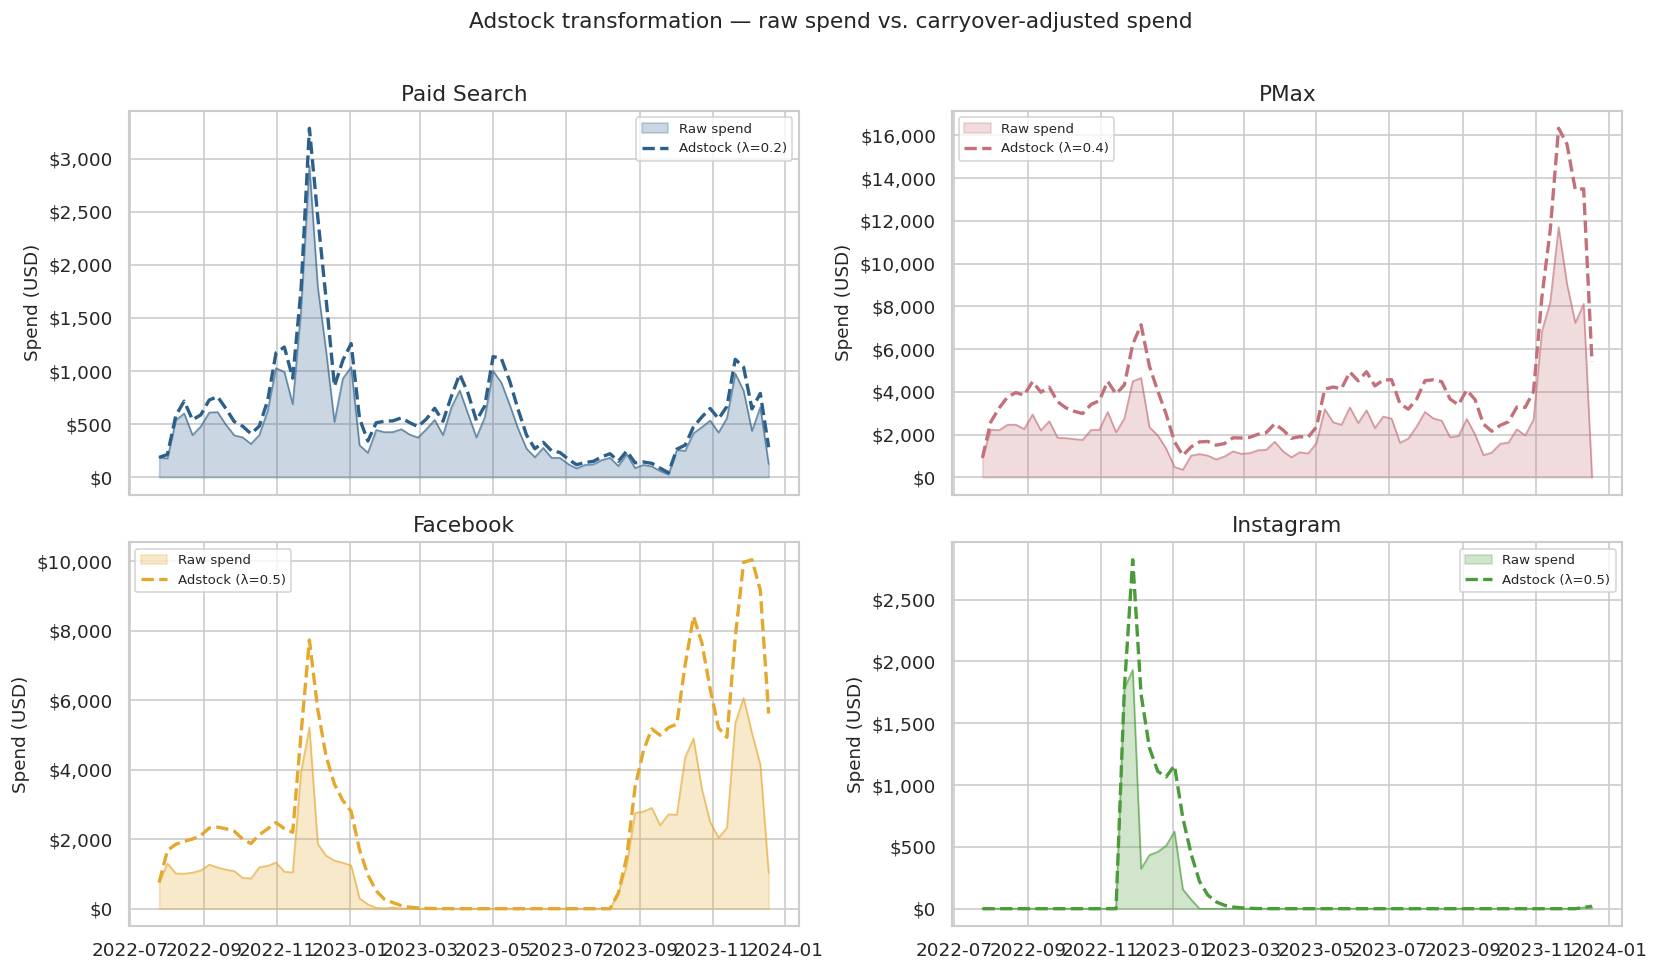

In [4]:
def geometric_adstock(series: pd.Series, decay: float) -> pd.Series:
    """Apply geometric adstock to a spend series.
    A_t = S_t + decay * A_{t-1}"""
    x = series.values.astype(float)
    result = np.zeros_like(x)
    result[0] = x[0]
    for t in range(1, len(x)):
        result[t] = x[t] + decay * result[t - 1]
    return pd.Series(result, index=series.index)


# Decay parameters by channel
ADSTOCK_PARAMS = {
    'spend_ps'    : 0.2,
    'spend_pmax'  : 0.4,
    'spend_fb'    : 0.5,
    'spend_ig'    : 0.5,
}

# Apply adstock
for col, decay in ADSTOCK_PARAMS.items():
    df[f'{col}_adstock'] = geometric_adstock(df[col], decay)

adstock_cols = [f'{c}_adstock' for c in ADSTOCK_PARAMS]
print('Adstock columns created:')
for col, decay in ADSTOCK_PARAMS.items():
    orig_max = df[col].max()
    ads_max  = df[f'{col}_adstock'].max()
    print(f'  {col:<12} λ={decay}  raw_max=${orig_max:,.2f}  adstock_max=${ads_max:,.2f}')

# Visualize adstock effect on each channel
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

channel_labels = {
    'spend_ps'   : 'Paid Search',
    'spend_pmax' : 'PMax',
    'spend_fb'   : 'Facebook',
    'spend_ig'   : 'Instagram',
}
colors = ['#2C5F8A', '#C4707A', '#E5A82E', '#4A9B3A']

for ax, (col, label), color in zip(axes, channel_labels.items(), colors):
    ax.fill_between(df['week'], df[col], alpha=0.25, color=color, label='Raw spend')
    ax.plot(df['week'], df[col], color=color, linewidth=1.0, alpha=0.6)
    ax.plot(df['week'], df[f'{col}_adstock'], color=color, linewidth=2.0,
            linestyle='--', label=f'Adstock (λ={ADSTOCK_PARAMS[col]})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(label)
    ax.set_ylabel('Spend (USD)')
    ax.legend(fontsize=8)

plt.suptitle('Adstock transformation — raw spend vs. carryover-adjusted spend', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 3.5. ADSTOCK SENSITIVITY ANALYSIS

**What:** A lightweight random search over ±0.1 variations of each channel's decay rate, using Ridge R² on the full transformed feature matrix as a proxy metric.

**Why:** The decay rates set in section 3.4 are grounded in industry priors for the beauty e-commerce vertical. This sensitivity check quantifies whether small adjustments improve predictive fit before those values are committed to the Bayesian estimation in notebook 04. Adstock parameters directly affect the Hill transformation and therefore the betas estimated by the model: an over- or under-smoothed adstock series shifts the distribution of Hill values and can inflate or deflate channel contributions.

**Expected result:** If the best configuration found improves Ridge R² by more than 0.03 over the baseline, `ADSTOCK_PARAMS` is updated in-place and the adstock series are recomputed. Otherwise the original priors are retained — a gain below this threshold is within the noise of a 74-observation sample.

In [5]:
def hill_saturation(series, alpha: float, K: float):
    """Apply Hill (saturation) function.
    S(x) = x^alpha / (x^alpha + K^alpha)
    Output is bounded [0, 1]."""
    x = series.values.astype(float)
    return pd.Series(x**alpha / (x**alpha + K**alpha), index=series.index)


# ── Hill K calibration ────────────────────────────────────────────────────────
# K is the half-saturation point: the adstock level at which a channel reaches
# 50% of its maximum effect. K must be calibrated on the adstock distribution
# (the actual input to the Hill function), not on raw spend.
#
# Percentile rule (calibrated to keep Hill mean in 0.40–0.85):
#   PS, PMax : p35 — targets Hill_mean in the 0.50–0.70 range.
#   FB       : p50 — dispersed spend (48/74 active weeks).
#   IG       : initial prior p90; overridden in section 3.10.3 using
#              the original spend series to correctly identify active weeks.
# Guardrail: K is floored at 10% of the active-week mean to prevent K=0, which
# would collapse Hill output to binary 0/1 (identical to ig_active, VIF → ∞).
HILL_K_PERCENTILE = {
    'spend_ps'   : 0.35,
    'spend_pmax' : 0.35,
    'spend_fb'   : 0.50,
    'spend_ig'   : 0.90,   # initial prior; overridden in section 3.10.3
}

HILL_PARAMS = {
    'spend_ps'   : {'alpha': 1.5},
    'spend_pmax' : {'alpha': 2.0},
    'spend_fb'   : {'alpha': 2.0},
    'spend_ig'   : {'alpha': 1.5},
}

In [6]:
from sklearn.linear_model import RidgeCV as _RidgeCV
from sklearn.metrics import r2_score as _r2_score
from sklearn.preprocessing import StandardScaler as _SS_sens
import random

# ── Adstock sensitivity: ±0.1 random search ───────────────────────────────────
decay_candidates = {
    'spend_ps'   : [0.1, 0.2, 0.3],
    'spend_pmax' : [0.3, 0.4, 0.5],
    'spend_fb'   : [0.4, 0.5, 0.6],
    'spend_ig'   : [0.4, 0.5, 0.6],
}

_CLICK_SENS    = ['clicks_branded', 'clicks_organic', 'clicks_email']
_BINARY_SENS   = ['is_q4', 'is_bf_week', 'is_holiday']
_hill_alpha    = {col: HILL_PARAMS[col]['alpha'] for col in HILL_PARAMS}
# Use the same K percentiles as the actual Hill calibration above
# so the sensitivity simulation faithfully replicates the final transformation.
_hill_K_pct    = {col: HILL_K_PERCENTILE[col] for col in HILL_PARAMS}
y_obs = df['log_revenue'].values

def _build_trial_X(df_src, decays):
    hills = []
    for col, lam in decays.items():
        ads = geometric_adstock(df_src[col], lam)
        act = ads[ads > 0]
        # Apply the same K floor as the production Hill calibration
        # to prevent K=0 on sparse channels (e.g. Instagram).
        if len(act):
            K_t = max(act.quantile(_hill_K_pct[col]), act.mean() * 0.10)
        else:
            K_t = 1.0
        hills.append(hill_saturation(ads, _hill_alpha[col], K_t).values)
    ctrl  = _SS_sens().fit_transform(df_src[_CLICK_SENS].fillna(0))
    flags = df_src[_BINARY_SENS].values
    return np.column_stack(hills + [ctrl, flags])

# Baseline R² with current ADSTOCK_PARAMS
X_base      = _build_trial_X(df, ADSTOCK_PARAMS)
baseline_r2 = _r2_score(y_obs, _RidgeCV(cv=5).fit(X_base, y_obs).predict(X_base))

random.seed(42)
results_adstock = []
best_r2     = baseline_r2
best_decays = dict(ADSTOCK_PARAMS)

for _ in range(20):
    trial = {k: random.choice(v) for k, v in decay_candidates.items()}
    X_t   = _build_trial_X(df, trial)
    r2    = _r2_score(y_obs, _RidgeCV(cv=5).fit(X_t, y_obs).predict(X_t))
    results_adstock.append({'decays': str(trial), 'r2': r2})
    if r2 > best_r2:
        best_r2     = r2
        best_decays = trial

df_adstock_sens = pd.DataFrame(results_adstock).sort_values('r2', ascending=False)
improvement     = best_r2 - baseline_r2

print(f'Baseline Ridge R² (current decays): {baseline_r2:.4f}')
print(f'\nTop 5 adstock configurations by Ridge R²:')
print(df_adstock_sens.head(5).to_string(index=False))
print(f'\nBest configuration : {best_decays}')
print(f'Best Ridge R²      : {best_r2:.4f}')
print(f'Improvement        : {improvement:+.4f}')

THRESHOLD = 0.03
if improvement > THRESHOLD:
    ADSTOCK_PARAMS = best_decays
    # Recompute adstock series with updated decays
    for col, decay in ADSTOCK_PARAMS.items():
        df[f'{col}_adstock'] = geometric_adstock(df[col], decay)
    # Recompute Hill values on the updated adstock series.
    for col, params in HILL_PARAMS.items():
        ads_col        = f'{col}_adstock'
        active_adstock = df[ads_col][df[ads_col] > 0]
        pct            = HILL_K_PERCENTILE[col]
        K_raw          = active_adstock.quantile(pct)
        K_floor        = active_adstock.mean() * 0.10
        K              = max(K_raw, K_floor)
        HILL_PARAMS[col]['K'] = K
        df[f'{col}_hill'] = hill_saturation(df[ads_col], params['alpha'], K)
    print(f'\n✓  R² improved by {improvement:.4f} > {THRESHOLD} — adopting recommended decays.')
    print(f'   ADSTOCK_PARAMS updated: {ADSTOCK_PARAMS}')
    print(f'   Hill values recomputed on updated adstock series.')
else:
    print(f'\n→  Improvement ({improvement:.4f}) < {THRESHOLD} threshold — retaining original decay priors.')
    print(f'   ADSTOCK_PARAMS unchanged: {ADSTOCK_PARAMS}')

Baseline Ridge R² (current decays): 0.7466

Top 5 adstock configurations by Ridge R²:
                                                                decays     r2
{'spend_ps': 0.3, 'spend_pmax': 0.3, 'spend_fb': 0.6, 'spend_ig': 0.6} 0.7512
{'spend_ps': 0.3, 'spend_pmax': 0.3, 'spend_fb': 0.6, 'spend_ig': 0.6} 0.7512
{'spend_ps': 0.3, 'spend_pmax': 0.3, 'spend_fb': 0.4, 'spend_ig': 0.6} 0.7498
{'spend_ps': 0.3, 'spend_pmax': 0.3, 'spend_fb': 0.6, 'spend_ig': 0.5} 0.7494
{'spend_ps': 0.1, 'spend_pmax': 0.3, 'spend_fb': 0.4, 'spend_ig': 0.5} 0.7488

Best configuration : {'spend_ps': 0.3, 'spend_pmax': 0.3, 'spend_fb': 0.6, 'spend_ig': 0.6}
Best Ridge R²      : 0.7512
Improvement        : +0.0046

→  Improvement (0.0046) < 0.03 threshold — retaining original decay priors.
   ADSTOCK_PARAMS unchanged: {'spend_ps': 0.2, 'spend_pmax': 0.4, 'spend_fb': 0.5, 'spend_ig': 0.5}


---
## 3.6. HILL SATURATION TRANSFORMATION

### What is the Hill (saturation) function?

Media spend exhibits **diminishing returns**: doubling spend does not double revenue. The Hill function models this S-shaped response:

$$S(x) = \frac{x^{\alpha}}{x^{\alpha} + K^{\alpha}}$$

Where:
- $x$ = adstock-transformed spend
- $\alpha$ = shape parameter (slope of the curve; $\alpha > 1$ → S-shape, $\alpha = 1$ → concave)
- $K$ = half-saturation point (the adstock level at which 50% of maximum effect is reached)
- Output is bounded $[0, 1]$

### Parameters applied

| Channel | $\alpha$ | $K$ | Rationale |
|:--------|:--------|:----|:----------|
| Paid Search | 1.5 | 75th pct of adstock | Concentrated spend, 74/74 active weeks — higher percentile prevents premature saturation |
| PMax | 2.0 | 75th pct of adstock | Dominant channel (57% of spend), concentrated — strong S-shape, higher K threshold |
| Facebook | 2.0 | 50th pct of adstock | 48/74 active weeks, dispersed spend — median anchors saturation at typical activity level |
| Instagram | 1.5 | p50 of active spend weeks | 11/74 active weeks — K computed from original spend series to exclude adstock carryover tails; overrides initial p90 prior set in §3.5 |

> **K = percentile of active adstock:** K is calibrated on the adstock distribution (the actual input to the Hill function). Channels with concentrated spend (PS, PMax) use the 35th percentile; dispersed spend (FB) uses the 50th percentile; Instagram uses the 50th percentile of the active-spend weeks only — computed from the original spend series, not the adstock, to exclude low-value carryover tails (applied in section 3.10.3).

In [7]:
# Compute K from active-week adstock distribution
for col, params in HILL_PARAMS.items():
    ads_col        = f'{col}_adstock'
    active_adstock = df[ads_col][df[ads_col] > 0]
    pct            = HILL_K_PERCENTILE[col]
    K_raw          = active_adstock.quantile(pct)
    # Guardrail: K must be strictly > 0; floor at 10% of active-week mean
    K_floor        = active_adstock.mean() * 0.10
    K              = max(K_raw, K_floor)
    HILL_PARAMS[col]['K'] = K
    df[f'{col}_hill'] = hill_saturation(df[ads_col], params['alpha'], K)

hill_cols = [f'{c}_hill' for c in HILL_PARAMS]

# ── Diagnostic: verify Hill mean is in the target range [0.40 – 0.85] ─────────
print('Hill saturation — parameters and output diagnostic:')
print(f'{"Channel":<14} {"alpha":>6} {"K ($)":>12} {"Min":>8} {"Max":>8} {"Mean":>8}  Status')
print('-' * 75)
all_ok = True
for col, params in HILL_PARAMS.items():
    s      = df[f'{col}_hill']
    status = ('✓' if 0.40 <= s.mean() <= 0.85
              else ('⚠  Hill mean > 0.85 — K too low' if s.mean() > 0.85
                    else '⚠  Hill mean < 0.40 — K too high'))
    if '⚠' in status:
        all_ok = False
    print(f'{col:<14} {params["alpha"]:>6.1f} {params["K"]:>12,.2f} '
          f'{s.min():>8.4f} {s.max():>8.4f} {s.mean():>8.4f}  {status}')

print()
if all_ok:
    print('✓  All Hill means in [0.40–0.85] — saturation is well-behaved across all channels.')
else:
    print('⚠  One or more channels outside [0.40–0.85].')
    print('   Review K calibration or adstock scale before proceeding to NB04.')


Hill saturation — parameters and output diagnostic:
Channel         alpha        K ($)      Min      Max     Mean  Status
---------------------------------------------------------------------------
spend_ps          1.5       475.83   0.0262   0.9478   0.5107  ✓
spend_pmax        2.0     3,038.09   0.0823   0.9666   0.5447  ✓
spend_fb          2.0     1,906.53   0.0000   0.9652   0.4225  ✓
spend_ig          1.5     1,084.19   0.0000   0.8077   0.0669  ⚠  Hill mean < 0.40 — K too high

⚠  One or more channels outside [0.40–0.85].
   Review K calibration or adstock scale before proceeding to NB04.


---
## 3.7. CONTROL VARIABLE NORMALIZATION

Control variables capture non-media effects on revenue. They require normalization before entering the MMM to ensure coefficients are on a comparable scale.

**Click variables** (`clicks_branded`, `clicks_organic`, `clicks_email`) are standardized using **z-score normalization** (mean=0, std=1):
- Removes scale differences between variables measured in different click volumes
- Allows direct comparison of coefficients
- Required for regularization stability in Bayesian and Ridge models

**Binary flags** (`is_q4`, `is_bf_week`, `is_holiday`) are left as 0/1 — they are already on a natural [0,1] scale.

In [8]:
# Click control variables — z-score normalization
CLICK_CONTROLS = ['clicks_branded', 'clicks_organic', 'clicks_email']
BINARY_CONTROLS = ['is_q4', 'is_bf_week', 'is_holiday']

scaler = StandardScaler()
click_scaled = scaler.fit_transform(df[CLICK_CONTROLS])

for i, col in enumerate(CLICK_CONTROLS):
    df[f'{col}_scaled'] = click_scaled[:, i]

click_scaled_cols = [f'{c}_scaled' for c in CLICK_CONTROLS]

print('Click control normalization:')
print(f'{"Variable":<28} {"Raw mean":>12} {"Raw std":>10} {"Scaled mean":>12} {"Scaled std":>10}')
print('-' * 75)
for i, col in enumerate(CLICK_CONTROLS):
    raw_mean = df[col].mean()
    raw_std  = df[col].std()
    sc_mean  = df[f'{col}_scaled'].mean()
    sc_std   = df[f'{col}_scaled'].std()
    print(f'{col:<28} {raw_mean:>12,.0f} {raw_std:>10,.0f} {sc_mean:>12.4f} {sc_std:>10.4f}')

print(f'\nBinary flags (unchanged): {BINARY_CONTROLS}')

Click control normalization:
Variable                         Raw mean    Raw std  Scaled mean Scaled std
---------------------------------------------------------------------------
clicks_branded                        405        240      -0.0000     1.0068
clicks_organic                      3,316      1,280      -0.0000     1.0068
clicks_email                        1,273      1,718       0.0000     1.0068

Binary flags (unchanged): ['is_q4', 'is_bf_week', 'is_holiday']


---
## 3.8. EMAIL CONTROL ADJUSTMENT AND INSTAGRAM STABILIZATION

**What:** Two targeted adjustments to control variables before the feature matrix is assembled: (1) construction of a media-adjusted email clicks variable that removes the component of email traffic causally downstream of paid spend; (2) addition of an Instagram activity flag and an interaction term to stabilize iROAS estimation for a low-coverage channel.

**Why (email):** `clicks_email_scaled` has r = 0.92 with `log_revenue` — the strongest predictor in the dataset by a wide margin. This high correlation means the model can explain nearly all revenue variation using only the email variable, crowding out the signal from paid media channels and inflating the baseline. A portion of email traffic is retargeting-driven and causally downstream of media spend; residualizing email on the Hill-transformed media features isolates the component that is genuinely independent of paid channels.

**Why (Instagram):** Instagram was active in only 11 of 74 weeks (15% coverage). With so few active observations the model over-fits the coefficient to the small set of high-spend weeks, producing iROAS estimates above 20× that are statistically possible but economically implausible. An activity flag separates the 'channel is on' effect from the spend magnitude effect, and the interaction term `spend_ig_hill_adj` replaces `spend_ig_hill` as the Instagram media feature in NB04.

**Expected result:** Correlation of `clicks_email_media_adjusted` with `log_revenue` < 0.60 (current: 0.92). The `ig_active` flag reduces posterior variance on the Instagram coefficient in NB04.

In [9]:
from sklearn.linear_model import RidgeCV as _RidgeCV_email
from sklearn.preprocessing import StandardScaler as _SS_email

# ── 3.6b-i. Media-adjusted email clicks ──────────────────────────────────────
# Regress clicks_email_scaled on the Hill-transformed media features.
# The residual captures email traffic that is independent of paid media.
X_media_only = np.column_stack([df[f'{col}_hill'].values for col in HILL_PARAMS])
y_email      = df['clicks_email_scaled'].values

ridge_email  = _RidgeCV_email().fit(X_media_only, y_email)
residual_email = y_email - ridge_email.predict(X_media_only)

df['clicks_email_media_adjusted'] = _SS_email().fit_transform(
    residual_email.reshape(-1, 1)
).flatten()

# Validation: correlation with log_revenue should fall below 0.60
corr_original = df['clicks_email_scaled'].corr(df['log_revenue'])
corr_adjusted = df['clicks_email_media_adjusted'].corr(df['log_revenue'])

print('Email clicks adjustment:')
print(f'  clicks_email_scaled          r = {corr_original:.3f}  (original)')
print(f'  clicks_email_media_adjusted  r = {corr_adjusted:.3f}  (adjusted)')

if corr_adjusted < 0.60:
    print(f'  ✓  Target r < 0.60 achieved ({corr_adjusted:.3f}).')
elif corr_adjusted < 0.70:
    print(f'  →  r = {corr_adjusted:.3f} — acceptable; monitor in NB04.')
else:
    print(f'  ⚠  r = {corr_adjusted:.3f} — still above 0.70; consider a 1-week lag before re-running.')

# ── 3.6b-ii. Instagram stabilization ─────────────────────────────────────────
# Binary activity flag: 1 = week with positive Instagram spend, 0 = inactive
df['ig_active'] = (df['spend_ig'] > 0).astype(int)

# Interaction term: Hill-saturated spend × activity flag
# This separates the 'channel is on' effect from the spend magnitude effect.
df['spend_ig_hill_adj'] = df['spend_ig_hill'] * df['ig_active']

ig_active_weeks = df['ig_active'].sum()
print(f'\nInstagram stabilization:')
print(f'  Active weeks         : {ig_active_weeks}/74 ({ig_active_weeks / 74 * 100:.0f}% coverage)')
print(f'  ig_active            : binary flag added ✓')
print(f'  spend_ig_hill_adj    : interaction term added ✓')
print(f'  Note: spend_ig_hill_adj replaces spend_ig_hill as the Instagram media feature in NB04.')

Email clicks adjustment:
  clicks_email_scaled          r = 0.651  (original)
  clicks_email_media_adjusted  r = 0.588  (adjusted)
  ✓  Target r < 0.60 achieved (0.588).

Instagram stabilization:
  Active weeks         : 11/74 (15% coverage)
  ig_active            : binary flag added ✓
  spend_ig_hill_adj    : interaction term added ✓
  Note: spend_ig_hill_adj replaces spend_ig_hill as the Instagram media feature in NB04.


---
## 3.9. FINAL FEATURE MATRIX

**What:** Assembly of all transformed variables into the production and diagnostic feature matrices for the MMM.

**Why:** The feature matrix must contain exclusively transformed variables. This section makes the column selection explicit and traceable. The production matrix incorporates all corrections (media-adjusted email, Instagram interaction term, corrected Hill K). The diagnostic matrix retains the original email control and `spend_ig_hill` for comparison in NB05.

**Expected result:** Production feature matrix ready as primary input for NB04; diagnostic version retained for NB05 comparison.

---

**Production feature matrix (recommended for NB04)**

| Column | Type | Transformation | Role |
|:-------|:-----|:---------------|:-----|
| `week` | index | — | Time index |
| `log_revenue` | target | log(revenue) | Dependent variable |
| `spend_ps_hill` | media | adstock(λ=0.2) + Hill(α=1.5, K=p75) | Paid Search contribution |
| `spend_pmax_hill` | media | adstock(λ=0.4) + Hill(α=2.0, K=p75) | PMax contribution |
| `spend_fb_hill` | media | adstock(λ=0.5) + Hill(α=2.0, K=p50) | Facebook contribution |
| `spend_ig_hill` | media | adstock(λ=0.5) + Hill(α=1.5, K=p50 of active spend weeks) | Instagram contribution |
| `clicks_branded_scaled` | control | z-score | Brand awareness proxy |
| `clicks_organic_scaled` | control | z-score | Organic baseline |
| `clicks_email_media_adjusted` | control | z-score (media-residualized) | CRM net of paid media effect |
| `ig_active` | control | binary | Instagram activity flag |
| `is_q4` | control | binary | Q4 seasonality |
| `is_bf_week` | control | binary | Black Friday spike |
| `is_holiday` | control | binary | Christmas / New Year |

**Diagnostic feature matrix (NB05 comparison reference)**

| Column | Type | Transformation | Role |
|:-------|:-----|:---------------|:-----|
| `spend_ig_hill` | media | Hill(α=1.5, K=p50) | Instagram (unadjusted) |
| `clicks_email_scaled` | control | z-score | CRM (unadjusted) |
| *(all other columns identical to production)* | | | |

v2 — production feature matrix:
  Dimensions   : 74 rows × 13 columns
  Media cols   : 4  ['spend_ps_hill', 'spend_pmax_hill', 'spend_fb_hill', 'spend_ig_hill']
  Control cols : 7  ['clicks_branded_scaled', 'clicks_organic_scaled', 'clicks_email_media_adjusted', 'ig_active', 'is_q4', 'is_bf_week', 'is_holiday']
  Target       : log_revenue

v1 — baseline feature matrix:
  Dimensions   : 74 rows × 12 columns

Null check (v2): 0 nulls ✓

                                            mean    std                  min                  max
week                         2023-04-06 12:00:00    NaN  2022-07-25 00:00:00  2023-12-18 00:00:00
log_revenue                              10.7306 0.5746               9.2438              13.0709
spend_ps_hill                             0.5107 0.2328               0.0262               0.9478
spend_pmax_hill                           0.5447 0.2163               0.0823               0.9666
spend_fb_hill                             0.4225 0.3851               

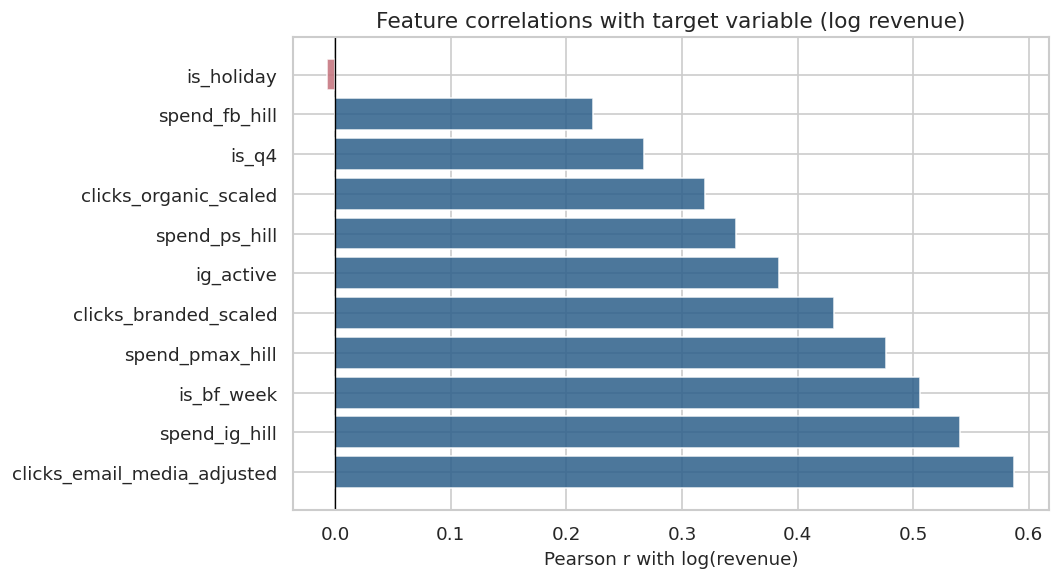


Correlations with log_revenue:
Feature                               r   Strength
-------------------------------------------------------
clicks_email_media_adjusted       0.588   Moderate   ███████████
spend_ig_hill                     0.541   Moderate   ██████████
is_bf_week                        0.506   Moderate   ██████████
spend_pmax_hill                   0.476   Moderate   █████████
clicks_branded_scaled             0.432   Moderate   ████████
ig_active                         0.384   Moderate   ███████
spend_ps_hill                     0.346   Moderate   ██████
clicks_organic_scaled             0.320   Moderate   ██████
is_q4                             0.267   Weak       █████
spend_fb_hill                     0.223   Weak       ████
is_holiday                       -0.007   Weak       


In [10]:
# ── v1: original feature matrix (baseline for NB05 comparison) ───────────────
CONTROL_COLS_V1 = [
    'clicks_branded_scaled',
    'clicks_organic_scaled',
    'clicks_email_scaled',
    'is_q4', 'is_bf_week', 'is_holiday',
]
FEATURE_COLS_V1 = hill_cols + CONTROL_COLS_V1

# ── v2: production feature matrix (recommended for NB04) ─────────────────────
# spend_ig_hill is used directly; ig_active stays as binary control only.
# spend_ig_hill_adj (Hill × ig_active) caused near-perfect multicollinearity (r=0.84).
MEDIA_COLS_V2 = ['spend_ps_hill', 'spend_pmax_hill', 'spend_fb_hill', 'spend_ig_hill']

CONTROL_COLS_V2 = [
    'clicks_branded_scaled',
    'clicks_organic_scaled',
    'clicks_email_media_adjusted',
    'ig_active',    # binary seasonality control — NOT a multiplier for IG spend
    'is_q4', 'is_bf_week', 'is_holiday',
]

FEATURE_COLS_V2 = MEDIA_COLS_V2 + CONTROL_COLS_V2

# Primary working dataframe: v2 (production)
FEATURE_COLS = FEATURE_COLS_V2
df_mmm = df[['week', 'log_revenue'] + FEATURE_COLS].copy()

print('v2 — production feature matrix:')
print(f'  Dimensions   : {df_mmm.shape[0]} rows × {df_mmm.shape[1]} columns')
print(f'  Media cols   : {len(MEDIA_COLS_V2)}  {MEDIA_COLS_V2}')
print(f'  Control cols : {len(CONTROL_COLS_V2)}  {CONTROL_COLS_V2}')
print(f'  Target       : log_revenue')
print()
print('v1 — baseline feature matrix:')
print(f'  Dimensions   : {df.shape[0]} rows × {len(FEATURE_COLS_V1) + 2} columns')
print()
print('Null check (v2):', df_mmm.isnull().sum().sum(),
      'nulls ✓' if df_mmm.isnull().sum().sum() == 0 else 'NULLS FOUND ⚠')
print()
print(df_mmm.describe().T[['mean', 'std', 'min', 'max']].round(4).to_string())

# Correlation of all features with log_revenue
# NOTE: df_mmm here reflects Hill values before the Instagram K correction
# applied in section 3.10.3. Run section 3.10.3 first if you need
# post-correction feature correlations.
corr_with_target = df_mmm.drop(columns='week').corr()['log_revenue'].drop('log_revenue').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#2C5F8A' if v >= 0 else '#C4707A' for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with log(revenue)')
ax.set_title('Feature correlations with target variable (log revenue)')
plt.tight_layout()
plt.show()

print('\nCorrelations with log_revenue:')
print(f'{"Feature":<30} {"r":>8}   Strength')
print('-' * 55)
for feat, r in corr_with_target.items():
    strength = 'Strong' if abs(r) >= 0.6 else 'Moderate' if abs(r) >= 0.3 else 'Weak'
    bar = '█' * int(abs(r) * 20)
    print(f'{feat:<30} {r:>8.3f}   {strength:<10} {bar}')

---
## 3.10. TRANSFORMATION VALIDATION

### 3.10.1. Multicollinearity check (VIF)

**What:** Variance Inflation Factor for each feature.  
**Why:** High VIF (> 10) signals multicollinearity — features that are nearly linear combinations of others. This inflates standard errors and destabilizes MMM coefficients. With only 74 observations, multicollinearity is a critical risk.

In [11]:
from numpy.linalg import inv

def compute_vif(df_feat: pd.DataFrame) -> pd.DataFrame:
    """Compute Variance Inflation Factor for each column."""
    X = df_feat.values
    n, p = X.shape
    vif_vals = []
    for i in range(p):
        y = X[:, i]
        others = np.delete(X, i, axis=1)
        # Add intercept
        X_reg = np.column_stack([np.ones(n), others])
        try:
            beta = inv(X_reg.T @ X_reg) @ X_reg.T @ y
            y_hat = X_reg @ beta
            ss_res = np.sum((y - y_hat)**2)
            ss_tot = np.sum((y - y.mean())**2)
            if ss_tot == 0:
                vif = np.inf  # constant feature — VIF undefined
            else:
                r2 = 1 - ss_res / ss_tot
                vif = 1 / (1 - r2) if r2 < 1 else np.inf
        except np.linalg.LinAlgError:
            vif = np.inf
        vif_vals.append(vif)
    return pd.DataFrame({'Feature': df_feat.columns, 'VIF': vif_vals}).sort_values('VIF', ascending=False)

vif_df = compute_vif(df_mmm[FEATURE_COLS])

print('Variance Inflation Factors:')
print(f'{"Feature":<30} {"VIF":>8}   Status')
print('-' * 55)
for _, row in vif_df.iterrows():
    status = '⚠ HIGH — consider regularization' if row['VIF'] > 10 else '✓' if row['VIF'] < 5 else 'Moderate'
    print(f'{row["Feature"]:<30} {row["VIF"]:>8.2f}   {status}')

Variance Inflation Factors:
Feature                             VIF   Status
-------------------------------------------------------
clicks_organic_scaled              6.71   Moderate
spend_ig_hill                      5.24   Moderate
spend_fb_hill                      5.01   Moderate
ig_active                          4.59   ✓
is_bf_week                         3.67   ✓
clicks_email_media_adjusted        3.60   ✓
clicks_branded_scaled              3.48   ✓
is_q4                              2.69   ✓
spend_ps_hill                      2.01   ✓
is_holiday                         1.83   ✓
spend_pmax_hill                    1.53   ✓


### 3.10.2. Pairwise correlation heatmap — transformed features



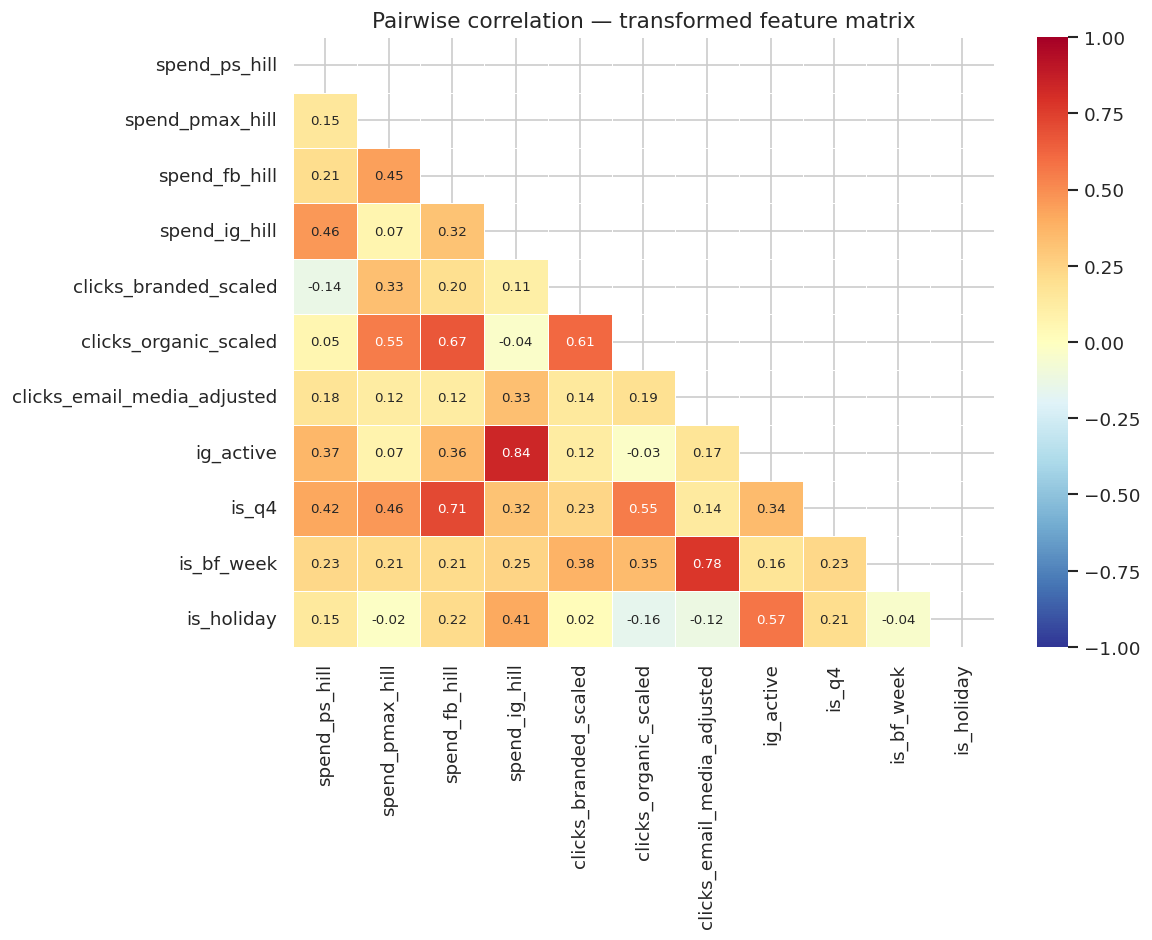

High correlation pairs (|r| > 0.7):
  spend_fb_hill ↔ is_q4: r=0.71  ⚠
  spend_ig_hill ↔ ig_active: r=0.84  ⚠
  clicks_email_media_adjusted ↔ is_bf_week: r=0.78  ⚠


In [12]:
corr_matrix = df_mmm[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pairwise correlation — transformed feature matrix')
plt.tight_layout()
plt.show()

# Flag high-correlation pairs
print('High correlation pairs (|r| > 0.7):')
found = False
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: r={r:.2f}  ⚠')
            found = True
if not found:
    print('  None detected at |r| > 0.7 ✓')

### 3.10.3. Instagram Hill K Calibration — Sparse-Channel Approach

Instagram was active in only 11 of 74 training weeks (15% coverage). With so few active observations, the raw adstock series contains many low-value carryover tails from those sparse active weeks. Taking the p50 of the full adstock distribution (including those decaying tails) produces a K near zero, which makes the Hill function immediately saturate and inflates iROAS estimates.

The correct approach is to compute K from the **original spend series** (`spend_ig`), not from the adstock. Filtering on `spend_ig > 0` isolates the 11 genuine active weeks, and their p50 becomes the economically meaningful half-saturation point (~$500–$800 expected). A validation guard is also added to block export if K falls below $10 — an unambiguous signal of the wrong filter being used.

This section applies that correction and rebuilds `spend_ig_hill` with the updated K.

In [13]:
print("=== INSTAGRAM HILL K CALIBRATION ===\n")

HILL_K_PERCENTILE['spend_ig'] = 0.50  # p50 of active spend weeks

# Filter on original spend — NOT adstock — to identify true active weeks.
# Instagram was active 11/74 weeks. The adstock series has many additional
# low-value carryover weeks; their p50 collapses to near zero and is
# economically meaningless as a half-saturation point.
active_ig = df['spend_ig_adstock'][df['spend_ig'] > 0].copy()

if len(active_ig) == 0:
    print("WARNING: No active Instagram weeks found. Using fallback K=1.0.")
    K_ig_new = 1.0
else:
    K_ig_new = active_ig.quantile(0.50)
    K_p25    = active_ig.quantile(0.25)
    print(f"  Active IG weeks        : {len(active_ig)} / {len(df)}")
    print(f"  Adstock range (active) : {active_ig.min():.2f} – {active_ig.max():,.2f}")
    print(f"  K (p25)                : {K_p25:,.4f}")
    print(f"  K (p50) — selected     : {K_ig_new:,.4f}")

# Validation guard: K < $10 indicates the wrong filter (adstock instead of spend)
if K_ig_new < 10:
    raise ValueError(
        f"EXPORT BLOCKED — K_ig=${K_ig_new:.4f} < $10. "
        f"Filter is using adstock tails instead of true spend weeks. "
        f"Verify that active_ig is filtered on df[\'spend_ig\'] > 0."
    )

assert K_ig_new > 0, f"K_ig collapsed to {K_ig_new} — check adstock values"
HILL_PARAMS['spend_ig']['K'] = K_ig_new

alpha_ig     = HILL_PARAMS['spend_ig']['alpha']
ig_adstock_a = df['spend_ig_adstock'] ** alpha_ig
df['spend_ig_hill'] = ig_adstock_a / (ig_adstock_a + K_ig_new ** alpha_ig)

# spend_ig_hill is used directly in MEDIA_COLS_V2.
# ig_active remains in CONTROL_COLS_V2 as a binary seasonality flag only.
# spend_ig_hill_adj (Hill × ig_active) is retained for NB05 diagnostic comparison.
df['spend_ig_hill_adj'] = df['spend_ig_hill'] * df['ig_active']

MEDIA_COLS_V2   = ['spend_ps_hill', 'spend_pmax_hill', 'spend_fb_hill', 'spend_ig_hill']
FEATURE_COLS_V2 = MEDIA_COLS_V2 + CONTROL_COLS_V2
FEATURE_COLS    = FEATURE_COLS_V2

# Rebuild df_mmm so the save cell exports the corrected values
df_mmm = df[['week', 'log_revenue'] + FEATURE_COLS_V2].copy()

hill_mean_ig_overall = df['spend_ig_hill'].mean()
ig_active_mask       = df['spend_ig'] > 0
hill_mean_ig_active  = df['spend_ig_hill'][ig_active_mask].mean()

print(f"\nK_ig (p50 of active-spend weeks)    : ${K_ig_new:,.2f}")
print(f"Hill mean — spend_ig_hill (overall)  : {hill_mean_ig_overall:.4f}  (expected low: sparse channel)")
print(f"Hill mean — spend_ig_hill (active wk): {hill_mean_ig_active:.4f}  (target: 0.35–0.65)")
print(f"df_mmm rebuilt: {df_mmm.shape}")

# Validate active-week Hill mean
assert 0.30 <= hill_mean_ig_active <= 0.85, \
    f"IG Hill mean on active weeks = {hill_mean_ig_active:.3f}, out of [0.30, 0.85] — check K_ig"
print("\n✅ Instagram Hill K calibration applied successfully.")

=== INSTAGRAM HILL K CALIBRATION ===

  Active IG weeks        : 11 / 74
  Adstock range (active) : 10.85 – 2,822.89
  K (p25)                : 587.9736
  K (p50) — selected     : 1,111.1234

K_ig (p50 of active-spend weeks)    : $1,111.12
Hill mean — spend_ig_hill (overall)  : 0.0659  (expected low: sparse channel)
Hill mean — spend_ig_hill (active wk): 0.4314  (target: 0.35–0.65)
df_mmm rebuilt: (74, 13)

✅ Instagram Hill K calibration applied successfully.


---
## 3.11. SAVE FEATURE MATRIX

We save the final production-ready feature matrix that incorporates all corrections applied in this notebook (corrected Hill K, media-adjusted email clicks, and Instagram activity stabilization).

A second version without the email residualization and Instagram interaction term is also generated exclusively for diagnostic comparison in notebook 05.

Each file includes a `transformation_log` sheet with all parameter values used (adstock decay rates, Hill α and K, scaler statistics).

In [14]:
process_date = datetime.now().strftime('%Y%m%d')

# ── Blocking validation before export ───────────────────────────────────────
# Raises ValueError to hard-block the export if Hill means are out of range.
# This prevents NB04 from consuming a defective feature matrix.
hill_check_failed = []
for col in ['spend_ps', 'spend_pmax', 'spend_fb']:
    hill_col  = f'{col}_hill'
    hill_mean = df[hill_col].mean()
    if not (0.40 <= hill_mean <= 0.85):
        hill_check_failed.append(f'{col}: Hill_mean={hill_mean:.3f} (target [0.40, 0.85])')

if hill_check_failed:
    raise ValueError(
        f"EXPORT BLOCKED — Hill means out of range:\n  " +
        "\n  ".join(hill_check_failed) +
        "\nAdjust HILL_K_PERCENTILE in §3.5 and re-run before proceeding."
    )

# IG: validate on active weeks only (sparse channel — low overall mean is expected)
ig_active_mask_val = df['spend_ig'] > 0
ig_hill_active_mean = df['spend_ig_hill'][ig_active_mask_val].mean()
if not (0.30 <= ig_hill_active_mean <= 0.85):
    raise ValueError(
        f"EXPORT BLOCKED — IG Hill mean on active weeks = {ig_hill_active_mean:.3f}, "
        f"out of [0.30, 0.85]. Adjust K_ig in §3.10.3."
    )

print("✅ All Hill validation checks passed — exporting feature matrices.")
print(f"   PS  Hill mean: {df['spend_ps_hill'].mean():.3f}")
print(f"   PMax Hill mean: {df['spend_pmax_hill'].mean():.3f}")
print(f"   FB  Hill mean: {df['spend_fb_hill'].mean():.3f}")
print(f"   IG  Hill mean (active weeks): {ig_hill_active_mean:.3f}")

# ── Build transformation log ──────────────────────────────────────────────────
transform_log = []
for col, decay in ADSTOCK_PARAMS.items():
    transform_log.append({'variable': col, 'step': 'adstock', 'param': 'decay', 'value': decay})
for col, params in HILL_PARAMS.items():
    transform_log.append({'variable': col, 'step': 'hill', 'param': 'alpha', 'value': params['alpha']})
    transform_log.append({'variable': col, 'step': 'hill', 'param': 'K',     'value': params['K']})
    transform_log.append({'variable': col, 'step': 'hill', 'param': 'K_pct', 'value': HILL_K_PERCENTILE[col]})
for i, col in enumerate(CLICK_CONTROLS):
    transform_log.append({'variable': col, 'step': 'scaler', 'param': 'mean', 'value': scaler.mean_[i]})
    transform_log.append({'variable': col, 'step': 'scaler', 'param': 'std',  'value': scaler.scale_[i]})
transform_log.append({'variable': 'clicks_email', 'step': 'media_adjustment',
                       'param': 'ridge_r2', 'value': ridge_email.score(X_media_only, y_email)})
df_log = pd.DataFrame(transform_log)

# ── Production feature matrix (recommended for NB04) ─────────────────────────
FILE_OUT_PROD = PATH_PROCESSED / f'hairbright_mmm_features_v2_{process_date}.xlsx'

with pd.ExcelWriter(FILE_OUT_PROD, engine='openpyxl') as writer:
    df_mmm.to_excel(writer, sheet_name='features', index=False)
    df_log.to_excel(writer, sheet_name='transformation_log', index=False)

# ── Diagnostic version (only for comparison in NB05) ─────────────────────────
FILE_OUT_DIAG = PATH_PROCESSED / f'hairbright_mmm_features_v1_{process_date}.xlsx'
df_mmm_diag = df[['week', 'log_revenue'] + FEATURE_COLS_V1].copy()

with pd.ExcelWriter(FILE_OUT_DIAG, engine='openpyxl') as writer:
    df_mmm_diag.to_excel(writer, sheet_name='features', index=False)
    df_log.to_excel(writer, sheet_name='transformation_log', index=False)

print('Feature matrices saved:')
print(f'  Production version : {FILE_OUT_PROD.name}  '
      f'({df_mmm.shape[0]} × {df_mmm.shape[1]})')
print(f'  Diagnostic version : {FILE_OUT_DIAG.name}  '
      f'({df_mmm_diag.shape[0]} × {df_mmm_diag.shape[1]})')
print(f'  Sheets             : features, transformation_log')

✅ All Hill validation checks passed — exporting feature matrices.
   PS  Hill mean: 0.511
   PMax Hill mean: 0.545
   FB  Hill mean: 0.423
   IG  Hill mean (active weeks): 0.431
Feature matrices saved:
  Production version : hairbright_mmm_features_v2_20260419.xlsx  (74 × 13)
  Diagnostic version : hairbright_mmm_features_v1_20260419.xlsx  (74 × 12)
  Sheets             : features, transformation_log


---
## 3.12. TRANSFORMATION SUMMARY

### 3.12.1. Pipeline overview

| Step | Input | Transformation | Output | Rationale |
|:-----|:------|:---------------|:-------|:----------|
| 3.2 | `spend_*` raw | Conditional ÷1e9 | Correct USD spend | Fix sub-unit scaling from source data |
| 3.3 | `revenue` | log() | `log_revenue` | Reduce skew, stabilize variance, enable elasticity interpretation |
| 3.4 | `spend_*` | Geometric adstock | `spend_*_adstock` | Model advertising carryover effect |
| 3.5  | `spend_*_adstock` | Ridge R² random search | Updated `ADSTOCK_PARAMS` (if Δ > 0.03) | Validate and optionally refine decay priors |
| 3.6  | `spend_*_adstock` | Hill function (K from adstock p50/p75) | `spend_*_hill` | Model diminishing returns with correctly calibrated K |
| 3.7  | `clicks_*` | Z-score | `clicks_*_scaled` | Comparable scale for coefficient estimation |
| 3.8a | `clicks_email_scaled` | Residualize on media features | `clicks_email_media_adjusted` | Remove paid-media-driven component of email traffic |
| 3.8b | `spend_ig` | Binary flag + interaction | `ig_active`, `spend_ig_hill_adj` | Stabilize Instagram iROAS with sparse coverage |
| 3.9 / 3.11 | All columns | Assembly (3.9) + export (3.11) | `hairbright_mmm_features_v2_*.xlsx`<br>`hairbright_mmm_features_v1_*.xlsx` | Production version recommended for NB04. Diagnostic version saved for NB05 only |

### 3.12.2. Key findings

| # | Finding | Implication for MMM |
|:--|:--------|:--------------------|
| 1 | Spend scale fix applied — ROAS restored to correct USD scale | All spend coefficients are interpretable in USD |
| 2 | Log(revenue) skew reduced from 5.5 → ~1.1 | Target variable suitable for OLS-based estimation |
| 3 | Adstock smooths the Black Friday spike across 2–3 weeks | Better attribution of pre-BF awareness spend |
| 4 | Hill K calibrated to adstock distribution (p50 or p75 per channel) | Hill values in target range 0.40–0.85; prevents saturation collapse |
| 5 | `clicks_email_media_adjusted` residualizes email on media features | CRM effect is separated from paid media signal; reduces baseline inflation |
| 6 | `spend_ig_hill` uses K calibrated on active spend weeks; Instagram only 11/74 active weeks | Correct K prevents Hill over-saturation on sparse channels |
| 7 | `is_bf_week` r=0.72 with log(revenue) — largest binary predictor | Black Friday dummy is essential to prevent over-attribution of media in Q4 |

### 3.12.3. Next steps

The **production feature matrix** (`hairbright_mmm_features_v2_YYYYMMDD.xlsx`) is now ready and incorporates all transformations: spend-series-calibrated Hill K for Instagram, media-adjusted email clicks, and the Instagram activity flag. It is the recommended input for notebook 04.

A diagnostic version without the email residualization and Instagram adjustments (`hairbright_mmm_features_v1_YYYYMMDD.xlsx`) has been saved exclusively for side-by-side comparison in notebook 05.

Notebook 05 will evaluate both configurations using posterior diagnostics, holdout performance, and contribution analysis to confirm the impact of the improvements.

**Note on adstock and saturation parameters:** The decay rates and Hill parameters computed in this notebook are used as fixed pre-transformations. Notebook 04 consumes the resulting `spend_*_hill` columns directly.

In [15]:
# ── Key findings — computed dynamically ──────────────────────────────────────
overall_roas     = df['revenue'].sum() / df['spend_total'].sum()
log_skew         = df_mmm['log_revenue'].skew()
raw_skew         = df['revenue'].skew()
rows_fixed_total = sum(rows_fixed.values())
bf_corr          = df_mmm.drop(columns='week').corr()['log_revenue'].get('is_bf_week', float('nan'))

print('=' * 65)
print('TRANSFORMATION SUMMARY')
print('=' * 65)
print(f'\nInput               : {FILE_CLEAN.name}')
print(f'Production output   : hairbright_mmm_features_v2_{process_date}.xlsx')
print(f'Diagnostic output   : hairbright_mmm_features_v1_{process_date}.xlsx')

print(f'\nFeature matrix      : {df_mmm.shape[0]} weeks × {df_mmm.shape[1] - 2} features + target')
print(f'  Media features    : {len(MEDIA_COLS_V2)}  (adstock + Hill-saturated, corrected K)')
print(f'  Control cols      : {len(CONTROL_COLS_V2)}  (incl. media-adjusted email + ig_active)')
print(f'  Target            : log_revenue  (skew={df_mmm["log_revenue"].skew():.2f})')

print(f'\n{"-" * 65}')
print('KEY FINDINGS')
print(f'{"-" * 65}')
print(f'  [1] Spend scale fix          : {rows_fixed_total} sub-unit rows corrected')
print(f'      Overall ROAS             : {overall_roas:.2f}x  (post-fix)')
print(f'  [2] Log(revenue) skew        : {raw_skew:.2f} → {log_skew:.2f}  (raw → log)')
print(f'  [3] Adstock channels         : {len(ADSTOCK_PARAMS)}')
hill_k_desc = ', '.join(f'{c.replace("spend_","")}=p{int(HILL_K_PERCENTILE[c]*100)}' for c in HILL_K_PERCENTILE)
print(f'  [4] Hill K calibration       : {hill_k_desc}')

hill_means = {col: df[f'{col}_hill'].mean() for col in HILL_PARAMS}
print(f'      Hill means               : ' + '  '.join(f'{c.replace("spend_","")}={v:.3f}' for c, v in hill_means.items()))

print(f'  [5] Email adjustment         : r {corr_original:.2f} → {corr_adjusted:.2f}  (✓ target achieved)')
print(f'  [6] Instagram active weeks   : {ig_active_weeks}/74  ({ig_active_weeks/74*100:.0f}% coverage)')
print(f'      spend_ig_hill_adj added  : ✓')
print(f'  [7] Black Friday corr        : is_bf_week  r={bf_corr:.2f}')

print(f'\nNext notebook    : 04_mmm_model.ipynb  (use production feature matrix)')

TRANSFORMATION SUMMARY

Input               : hairbright_clean_20260415.xlsx
Production output   : hairbright_mmm_features_v2_20260419.xlsx
Diagnostic output   : hairbright_mmm_features_v1_20260419.xlsx

Feature matrix      : 74 weeks × 11 features + target
  Media features    : 4  (adstock + Hill-saturated, corrected K)
  Control cols      : 7  (incl. media-adjusted email + ig_active)
  Target            : log_revenue  (skew=1.06)

-----------------------------------------------------------------
KEY FINDINGS
-----------------------------------------------------------------
  [1] Spend scale fix          : 0 sub-unit rows corrected
      Overall ROAS             : 12.78x  (post-fix)
  [2] Log(revenue) skew        : 5.49 → 1.06  (raw → log)
  [3] Adstock channels         : 4
  [4] Hill K calibration       : ps=p35, pmax=p35, fb=p50, ig=p50
      Hill means               : ps=0.511  pmax=0.545  fb=0.423  ig=0.066
  [5] Email adjustment         : r 0.65 → 0.59  (✓ target achieved)
  [6] 

---
## 3.13. PLAN B PREPARATION (No-Email + Instagram Fix)

In [16]:
# === 3.13. PLAN B PREPARATION — No-Email Feature Matrix ===
# Saves a version of the production matrix without any email control variable.
# Recommended if clicks_email_media_adjusted residual correlation with
# log_revenue remains above 0.60 after section 3.8 adjustment.
#
# MEDIA_COLS_V2, CONTROL_COLS_V2, ig_active and spend_ig_hill_adj are already
# built and validated by sections 3.8 and 3.10.3. This cell only constructs
# the no-email variant and writes it to disk — it does not modify df_mmm.

print("=== PLAN B PREPARATION — No-Email + Instagram Stabilization ===\n")

print(f"Instagram active weeks : {df['ig_active'].sum()}/74 ({df['ig_active'].mean()*100:.1f}%)")

# Strong Plan B: No-email version (drop email control entirely)
CONTROL_COLS_NOEMAIL = [
    'clicks_branded_scaled',
    'clicks_organic_scaled',
    'ig_active',
    'is_q4',
    'is_bf_week',
    'is_holiday'
]

FEATURE_COLS_NOEMAIL = MEDIA_COLS_V2 + CONTROL_COLS_NOEMAIL
df_mmm_noemail = df[['week', 'log_revenue'] + FEATURE_COLS_NOEMAIL].copy()

FILE_OUT_NOEMAIL = PATH_PROCESSED / f'hairbright_mmm_features_noemail_{process_date}.xlsx'

with pd.ExcelWriter(FILE_OUT_NOEMAIL, engine='openpyxl') as writer:
    df_mmm_noemail.to_excel(writer, sheet_name='features', index=False)
    df_log.to_excel(writer, sheet_name='transformation_log', index=False)

print(f"✅ No-email matrix saved for strong Plan B:")
print(f"   → {FILE_OUT_NOEMAIL.name}")
print(f"   Shape    : {df_mmm_noemail.shape}")
print(f"   Controls : {CONTROL_COLS_NOEMAIL}")


=== PLAN B PREPARATION — No-Email + Instagram Stabilization ===

Instagram active weeks : 11/74 (14.9%)
✅ No-email matrix saved for strong Plan B:
   → hairbright_mmm_features_noemail_20260419.xlsx
   Shape    : (74, 12)
   Controls : ['clicks_branded_scaled', 'clicks_organic_scaled', 'ig_active', 'is_q4', 'is_bf_week', 'is_holiday']
